# Chapter 13: Deploying scikit-learn Models in Production

Reproduksi dan pembahasan buku John Sukup, *scikit-learn Cookbook*, Third Edition (Packt, 2025). Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_13) beserta exercise solutions. Adaptasi metodologi dijelaskan pada bagian terkait. Dataset sintetis/bawaan dan output di bawah dipakai untuk memahami workflow pembelajaran mesin.

## Daftar Isi

- [Overview of Model Deployment](#overview-of-model-deployment)
- [Serialization and Persistence Techniques](#serialization-and-persistence-techniques)
- [Scaling Models for Production](#scaling-models-for-production)
- [Monitoring and Updating Deployed Models](#monitoring-and-updating-deployed-models)
- [Managing the Model Life Cycle](#managing-the-model-life-cycle)
- [Setting Up Deployment Pipelines](#setting-up-deployment-pipelines)
- [Practical Exercises in Model Deployment](#practical-exercises-in-model-deployment)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})
chapter_results = {}

ARTIFACT_DIR = ROOT / 'tmp/deployment'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

## Overview of Model Deployment

Deployment mengemas preprocessing dan model agar menerima schema fitur yang sama lalu menghasilkan prediksi pada input baru. Bentuknya dapat batch, service online, atau embedded; kebutuhan latency, throughput, versioning, dan monitoring berbeda. Notebook ini mensimulasikan lifecycle lokal, tanpa membuka service internet atau menyatakan sistem produksi siap.

Model disimpan dengan joblib, dimuat kembali, lalu prediksi sebelum/sesudah dibandingkan. File model ditaruh pada tmp/deployment yang diabaikan Git. Input acak hanya smoke test bentuk API, bukan sampel berlabel untuk mengukur accuracy.

In [2]:
# Load the libraries
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

# Create and train a simple model
X, y = make_classification(n_samples=1000, n_features=20, random_state=2024)
clf = LogisticRegression(max_iter=1000, random_state=2024)
clf.fit(X, y)

LogisticRegression(max_iter=1000, random_state=2024)

In [3]:
# Save the trained model using joblib
dump(clf, ARTIFACT_DIR / "model.joblib")

# Load the model back
clf_loaded = load(ARTIFACT_DIR / "model.joblib")

# Make a prediction with the loaded model
incoming = np.random.rand(1, 20)
print(clf_loaded.predict(incoming))

np.testing.assert_array_equal(clf.predict(incoming), clf_loaded.predict(incoming))
chapter_results['joblib_prediction_equal'] = True

[1]


## Serialization and Persistence Techniques

pickle dan joblib menyimpan object Python; joblib efisien untuk array NumPy besar dan mendukung compression/memory mapping sesuai format. Keduanya dapat menjalankan kode saat load, sehingga hanya file tepercaya yang boleh dimuat. Model pada contoh dibuat oleh notebook sendiri. Penggunaan lintas versi scikit-learn tidak didukung sebagai kontrak kompatibilitas; dependency, schema, dan sumber training perlu dicatat.

Prediksi reload dibandingkan dengan object asal. Persamaan lima prediksi adalah smoke test serialization, bukan bukti kesetaraan seluruh perilaku. Alternatif seperti skops memberi kontrol tipe lebih ketat dan ONNX dapat melayani inferensi untuk estimator yang didukung; keduanya tidak menjadi dependency latihan ini.

In [4]:
# Load the libraries
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pickle
from joblib import dump, load

# Train a classifier
X, y = make_classification(n_samples=500, n_features=15, random_state=2024)
rf = RandomForestClassifier(n_estimators=10, random_state=2024)
rf.fit(X, y)

RandomForestClassifier(n_estimators=10, random_state=2024)

In [5]:
# Serialize using pickle
with open(ARTIFACT_DIR / "rf.pkl", "wb") as f:
    pickle.dump(rf, f)

# Serialize using joblib
dump(rf, ARTIFACT_DIR / "rf.joblib")

# Load the pickle model
with open(ARTIFACT_DIR / "rf.pkl", "rb") as f:
    rf1 = pickle.load(f)

# Load the joblib model
rf2 = load(ARTIFACT_DIR / "rf.joblib")

# Ensure identical behavior after loading
assert np.array_equal(rf.predict(X[:5]), rf1.predict(X[:5]))
assert np.array_equal(rf.predict(X[:5]), rf2.predict(X[:5]))

chapter_results['pickle_prediction_equal'] = True

## Scaling Models for Production

Batching mengurangi overhead per permintaan; n_jobs memparalelkan estimator atau CV pada CPU. Paralelisme bertingkat dapat oversubscribe CPU dan RAM, sehingga forest menggunakan dua worker dan CV menggunakan dua worker dengan estimator satu worker. Dask dapat menyediakan backend terdistribusi, tetapi tidak dijalankan pada latihan lokal.

Latency batch diukur dengan perf_counter setelah warm-up, bersama ukuran batch; latency satu pengukuran bukan SLA atau benchmark stabil. Throughput dan tail latency perlu diuji pada workload nyata. Kompresi, caching, resource limit, dan pencatatan environment membantu operasi, namun scaling tidak memperbaiki model yang salah.

In [6]:
# Load libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

# Train a forest model on synthetic data
X, y = make_classification(n_samples=2000, n_features=50, random_state=2024)
clf = RandomForestClassifier(n_estimators=100, n_jobs=2, random_state=2024)
clf.fit(X, y)

RandomForestClassifier(n_jobs=2, random_state=2024)

In [7]:
# Measure single-batch latency
batch = np.random.rand(1000, 50)
clf.predict(batch)  # warm-up
start = time.perf_counter()
clf.predict(batch)
batch_latency = time.perf_counter() - start
print("Batch size:", len(batch), "; latency (s):", batch_latency)

# Train with parallel cross-validation
scores = cross_val_score(RandomForestClassifier(n_estimators=50, n_jobs=1, random_state=2024), X, y, cv=3, n_jobs=2)
print("CV Accuracy:", np.mean(scores))

# (Optional) Use Dask as a joblib backend if available
# from dask.distributed import Client
# from dask_ml.model_selection import GridSearchCV as daskGSCV

chapter_results['batch_latency_seconds'] = batch_latency
chapter_results['parallel_cv_accuracy'] = float(np.mean(scores))

Batch size: 1000 ; latency (s): 0.08963760000006005


CV Accuracy: 0.8719986853420135


## Monitoring and Updating Deployed Models

Monitoring memisahkan kualitas input/schema, missing value, latency, distribusi fitur, dan kualitas prediksi ketika label tersedia. Data drift adalah perubahan distribusi input; concept drift adalah perubahan hubungan input–target. Accuracy membutuhkan label nyata yang sering datang terlambat; perubahan histogram saja bukan bukti concept drift.

SGDClassifier dilatih lewat partial_fit, lalu tiap batch baru dinilai sebelum pembaruan. Seed pembangkit berbeda membuat simulasi hubungan data berubah; ini ilustrasi perubahan distribusi, bukan stream produksi autentik. Jika skor batch minimum di bawah 0,8, model diperbarui sekali setelah monitoring. partial_fit melanjutkan optimasi; warm_start pada fit bukan pengganti jaminan pembelajaran incremental. Pembaruan harus divalidasi sebelum promosi model.

In [8]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

# Simulate initial training and streaming data
X_train, y_train = make_classification(n_samples=500, n_features=10, random_state=2024)
X_pub, y_pub = make_classification(n_samples=200, n_features=10, random_state=2025)
stream_batches = np.array_split(X_pub, 4)
stream_labels = np.array_split(y_pub, 4)

stream_X_train, stream_y_train = X_train.copy(), y_train.copy()

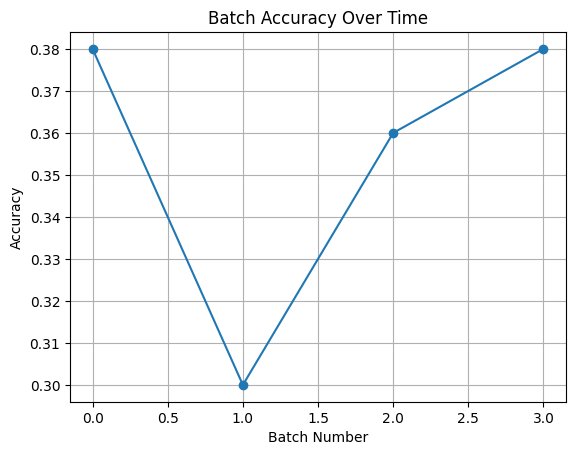

In [9]:
# Train an incremental SGDClassifier on initial data
clf = SGDClassifier(loss="log_loss", random_state=2024)
clf.partial_fit(X_train, y_train, classes=np.unique(y_train))

# Monitor each incoming batch
batch_scores = []
for xb, yb in zip(stream_batches, stream_labels):
    yf = clf.predict(xb)
    batch_scores.append(np.mean(yf == yb))

# Trigger retraining when accuracy drops below threshold (e.g. < 0.8)
if min(batch_scores) < 0.8:
    clf.partial_fit(X_pub, y_pub)

# Plot batch-by-batch accuracy
plt.plot(batch_scores, marker="o")
plt.title("Batch Accuracy Over Time")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

baseline_batch_scores = batch_scores.copy()
chapter_results['stream_batch_accuracy'] = [float(s) for s in batch_scores]
chapter_results['stream_update_triggered'] = bool(min(batch_scores) < 0.8)

## Managing the Model Life Cycle

Lifecycle mencakup dataset/version, kode training, parameter, artifact, evaluasi, promosi, monitoring, retraining, dan rollback. Metadata menyimpan versi library yang benar dari runtime, fitur, seed, serta skor holdout. Sumber memakai string versi 1.3.2 dan mengevaluasi sampel yang sudah dilatih; kedua masalah diperbaiki dengan metadata aktual dan split sebelum fit.

Artifact dan snapshot validation diberi versi v1.0. Menyimpan filename berversi belum menjadi registry penuh atau audit otomatis. Penggunaan data sensitif, akses artifact, retensi, dan kemampuan rollback perlu keputusan operasi tersendiri untuk aplikasi nyata.

In [10]:
# Load libraries
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from joblib import dump
import json

# Train a model and simulate versioning environment
X, y = make_classification(n_samples=800, n_features=20, random_state=2024)
clf = RandomForestClassifier(n_estimators=50, random_state=2024)
from sklearn.model_selection import train_test_split
X_train, Xv, y_train, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=2024)
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=2024)

In [11]:
import sklearn
version = 'v1.0'
artifact = ARTIFACT_DIR / f'rf_{version}.joblib'
dump(clf, artifact)
yv_pred = load(artifact).predict(Xv)
val_acc = accuracy_score(yv, yv_pred)
meta = {'version':version, 'sklearn':sklearn.__version__, 'numpy':np.__version__,
        'n_features':clf.n_features_in_, 'random_state':2024,
        'training_samples':len(X_train), 'validation_samples':len(Xv),
        'validation_accuracy':val_acc, 'parameters':clf.get_params()}
(ARTIFACT_DIR / f'rf_{version}_metadata.json').write_text(json.dumps(meta, indent=2), encoding='utf-8')
np.savez_compressed(ARTIFACT_DIR / f'rf_{version}_validation.npz', X=Xv, y=yv, predicted=yv_pred)
chapter_results['versioned_holdout_accuracy'] = val_acc
chapter_results['actual_sklearn_version'] = meta['sklearn']
display(meta)

{'version': 'v1.0',
 'sklearn': '1.5.2',
 'numpy': '2.1.3',
 'n_features': 20,
 'random_state': 2024,
 'training_samples': 600,
 'validation_samples': 200,
 'validation_accuracy': 0.945,
 'parameters': {'bootstrap': True,
  'ccp_alpha': 0.0,
  'class_weight': None,
  'criterion': 'gini',
  'max_depth': None,
  'max_features': 'sqrt',
  'max_leaf_nodes': None,
  'max_samples': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'n_estimators': 50,
  'n_jobs': None,
  'oob_score': False,
  'random_state': 2024,
  'verbose': 0,
  'warm_start': False}}

## Setting Up Deployment Pipelines

Pipeline menyatukan scaler dan classifier sehingga transformasi inferensi sesuai training. Gate evaluasi menahan kandidat yang tidak memenuhi threshold; kelulusan hanyalah satu syarat, bukan bukti keamanan atau readiness sistem. Test harus memakai data berlabel yang relevan dan terpisah dari training.

Contoh sumber mengevaluasi label acak independen dari fitur, sehingga accuracy tidak mengukur kualitas model. Di sini validation berasal dari holdout dataset yang sama dan belum dipakai fit. Threshold 0,8 ditetapkan sebagai contoh sebelum evaluasi. Pesan gate hanya simulasi lokal; tidak melakukan deploy ke server.

In [12]:
# Load libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from joblib import dump, load
from sklearn.metrics import accuracy_score

# Create data and pipeline
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=2024))
])
X_train, Xt, y_train, yt = train_test_split(X, y, test_size=0.25, stratify=y, random_state=2024)
pipe.fit(X_train, y_train)

Pipeline(steps=[('scale', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=2024))])

In [13]:
dump(pipe, ARTIFACT_DIR / 'pipeline.joblib')
prod_pipe = load(ARTIFACT_DIR / 'pipeline.joblib')
np.testing.assert_array_equal(pipe.predict(Xt), prod_pipe.predict(Xt))
acc = accuracy_score(yt, prod_pipe.predict(Xt))
threshold = 0.8
gate_passed = bool(acc > threshold)
print('Holdout accuracy:', acc, '; threshold:', threshold)
print('Local gate passed' if gate_passed else 'Local gate rejected; review model')
chapter_results['pipeline_holdout_accuracy'] = acc
chapter_results['pipeline_gate_passed'] = gate_passed

Holdout accuracy: 0.88 ; threshold: 0.8
Local gate passed


## Practical Exercises in Model Deployment

Exercise 1 menyimpan/memuat pipeline dan membandingkan prediksi. Exercise 2 memakai regularisasi lebih kuat pada data streaming yang sama untuk membandingkan monitoring; “lebih kuat” tidak selalu menjamin accuracy lebih rendah. Data awal streaming disimpan terpisah agar tidak tertimpa dataset resep lain.

Exercise 3 membagi satu dataset menjadi training/validation, mengekspor kandidat, lalu mengevaluasi threshold. Seed make_classification yang berbeda dapat mengubah aturan kelas, sehingga tidak dipakai sebagai pengganti holdout IID. Keputusan gate dicatat bersama skor dan threshold sehingga alasan menerima atau menolak kandidat dapat ditelusuri. Seluruhnya berjalan lokal dan tidak menerbitkan service.

In [14]:
# Load libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

# Create and train pipeline
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=2024))
])
pipe.fit(X, y)

# Save and reload pipeline
dump(pipe, ARTIFACT_DIR / "model_pipeline.joblib")
loaded_pipe = load(ARTIFACT_DIR / "model_pipeline.joblib")

# Generate new predictions
print(loaded_pipe.predict(X[:5]))

np.testing.assert_array_equal(pipe.predict(X[:5]), loaded_pipe.predict(X[:5]))
chapter_results['exercise_pipeline_prediction_equal'] = True

[1 1 1 0 0]


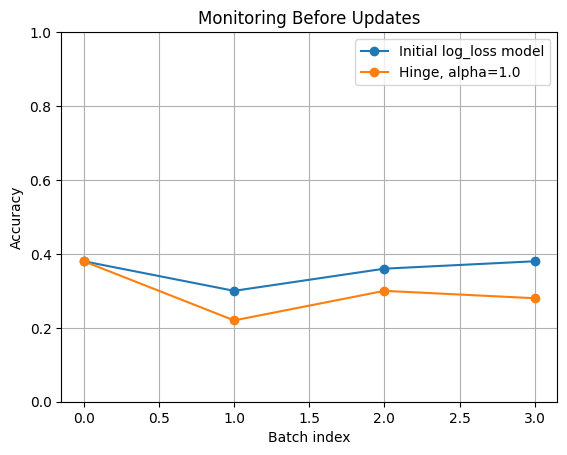

In [15]:
strong_clf = SGDClassifier(loss='hinge', alpha=1.0, random_state=2024)
strong_clf.partial_fit(stream_X_train, stream_y_train, classes=np.unique(stream_y_train))
strong_batch_scores = [float(np.mean(strong_clf.predict(xb) == yb))
                       for xb,yb in zip(stream_batches, stream_labels)]
plt.plot(baseline_batch_scores, marker='o', label='Initial log_loss model')
plt.plot(strong_batch_scores, marker='o', label='Hinge, alpha=1.0')
plt.xlabel('Batch index'); plt.ylabel('Accuracy'); plt.ylim(0, 1)
plt.title('Monitoring Before Updates'); plt.legend(); plt.grid(True); plt.show()
chapter_results['strong_regularization_batch_accuracy'] = strong_batch_scores

In [16]:
X, y = make_classification(n_samples=400, n_features=10, random_state=2024)
idx_train, idx_val = train_test_split(np.arange(len(X)), test_size=0.25, stratify=y, random_state=2024)
assert not set(idx_train) & set(idx_val)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024))
model.fit(X[idx_train], y[idx_train])
dump(model, ARTIFACT_DIR / 'model_ci.joblib')
model_prod = load(ARTIFACT_DIR / 'model_ci.joblib')
pred = model_prod.predict(X[idx_val])
acc = accuracy_score(y[idx_val], pred)
threshold = 0.8
approved = bool(acc > threshold)
print(f'Validation accuracy: {acc:.3f}; threshold: {threshold}')
print('Local gate approved' if approved else 'Local gate rejected')
chapter_results['exercise_ci_accuracy'] = acc
chapter_results['exercise_ci_gate_passed'] = approved
chapter_results['artifact_count'] = len(list(ARTIFACT_DIR.glob('*')))

Validation accuracy: 0.850; threshold: 0.8
Local gate approved


## Pemeriksaan Hasil

Assertion di bawah memeriksa konsistensi hasil dan keluaran, bukan membuktikan seluruh asumsi statistik.

In [17]:
assert chapter_results
assert chapter_results['joblib_prediction_equal']
assert chapter_results['pickle_prediction_equal']
assert chapter_results['exercise_pipeline_prediction_equal']
assert chapter_results['batch_latency_seconds'] >= 0
assert len(chapter_results['stream_batch_accuracy']) == 4
print(json.dumps(chapter_results, indent=2))

{
  "joblib_prediction_equal": true,
  "pickle_prediction_equal": true,
  "batch_latency_seconds": 0.08963760000006005,
  "parallel_cv_accuracy": 0.8719986853420135,
  "stream_batch_accuracy": [
    0.38,
    0.3,
    0.36,
    0.38
  ],
  "stream_update_triggered": true,
  "versioned_holdout_accuracy": 0.945,
  "actual_sklearn_version": "1.5.2",
  "pipeline_holdout_accuracy": 0.88,
  "pipeline_gate_passed": true,
  "exercise_pipeline_prediction_equal": true,
  "strong_regularization_batch_accuracy": [
    0.38,
    0.22,
    0.3,
    0.28
  ],
  "exercise_ci_accuracy": 0.85,
  "exercise_ci_gate_passed": true,
  "artifact_count": 9
}


## Ringkasan Bab

Prediksi model joblib, pickle, dan pipeline yang dimuat kembali sesuai dengan object asal pada smoke test. Artifact forest berversi memakai scikit-learn **1.5.2** dan menghasilkan holdout accuracy **0.945**. Pipeline holdout mencapai **0.880**, sedangkan gate latihan mencapai **0.850**; keduanya melewati threshold contoh 0,8.

Accuracy stream sebelum update adalah **0.38, 0.30, 0.36, 0.38**, sehingga aturan monitoring memicu pembaruan. Ini memperlihatkan model yang tersimpan dapat gagal ketika hubungan input–target berubah. Latency batch dicatat pada output dan bergantung pada mesin; tidak digunakan sebagai SLA. Semua artifact berada di tmp/deployment dan gate hanya simulasi lokal, tanpa service produksi yang diterbitkan.